In [1]:
# 12.6 Q1 - Fruit Basket Random Forest Ensemble

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report)

In [3]:
df = pd.read_csv('datasets/fruit_basket.csv')
print("Shape:", df.shape)
print(df.head(10))
print()
print("Class distribution:")
print(df['fruit'].value_counts())

Shape: (200, 5)
    color  size_cm  weight_g  sweetness   fruit
0  purple    19.25    402.92       4.30  Orange
1  violet     9.98    268.20       1.70    Plum
2  indigo    22.58    495.30      10.46  Orange
3  violet    16.06    357.90       7.52    Plum
4  indigo     5.77    170.12       1.11   Grape
5  violet     6.16    159.51       1.30    Plum
6  indigo    18.25    617.36       3.75  Orange
7  purple     6.80    168.55      -0.82    Plum
8  violet    14.16    437.44       4.07    Plum
9  purple    24.82    668.07       5.95  Orange

Class distribution:
fruit
Orange    90
Plum      63
Grape     27
Apple     20
Name: count, dtype: int64


In [4]:
# Encode categorical features

In [5]:
df_enc = df.copy()
color_le = LabelEncoder()
fruit_le = LabelEncoder()
df_enc['color'] = color_le.fit_transform(df['color'])
df_enc['fruit'] = fruit_le.fit_transform(df['fruit'])

print("Color mapping:", dict(zip(color_le.classes_,
                                  color_le.transform(color_le.classes_))))
print("Fruit mapping:", dict(zip(fruit_le.classes_,
                                  fruit_le.transform(fruit_le.classes_))))

Color mapping: {'indigo': np.int64(0), 'purple': np.int64(1), 'violet': np.int64(2)}
Fruit mapping: {'Apple': np.int64(0), 'Grape': np.int64(1), 'Orange': np.int64(2), 'Plum': np.int64(3)}


In [6]:
X = df_enc[['color', 'size_cm', 'weight_g', 'sweetness']]
y = df_enc['fruit']
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (200, 4) y shape: (200,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (140, 4) Test: (60, 4)


In [8]:
# Train Random Forest (10 trees, entropy)

In [9]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy',
                                random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred,
      target_names=fruit_le.classes_))

Accuracy: 0.6666666666666666

              precision    recall  f1-score   support

       Apple       0.20      0.17      0.18         6
       Grape       0.75      0.38      0.50         8
      Orange       0.66      0.85      0.74        27
        Plum       0.81      0.68      0.74        19

    accuracy                           0.67        60
   macro avg       0.60      0.52      0.54        60
weighted avg       0.67      0.67      0.65        60



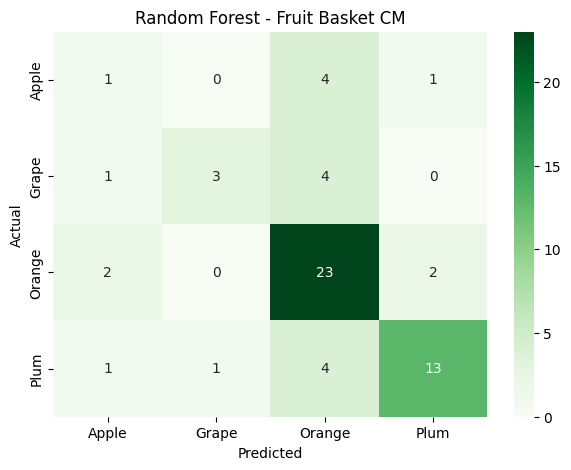

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=fruit_le.classes_,
            yticklabels=fruit_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Fruit Basket CM')
plt.show()

In [11]:
# Visualise one tree from the forest

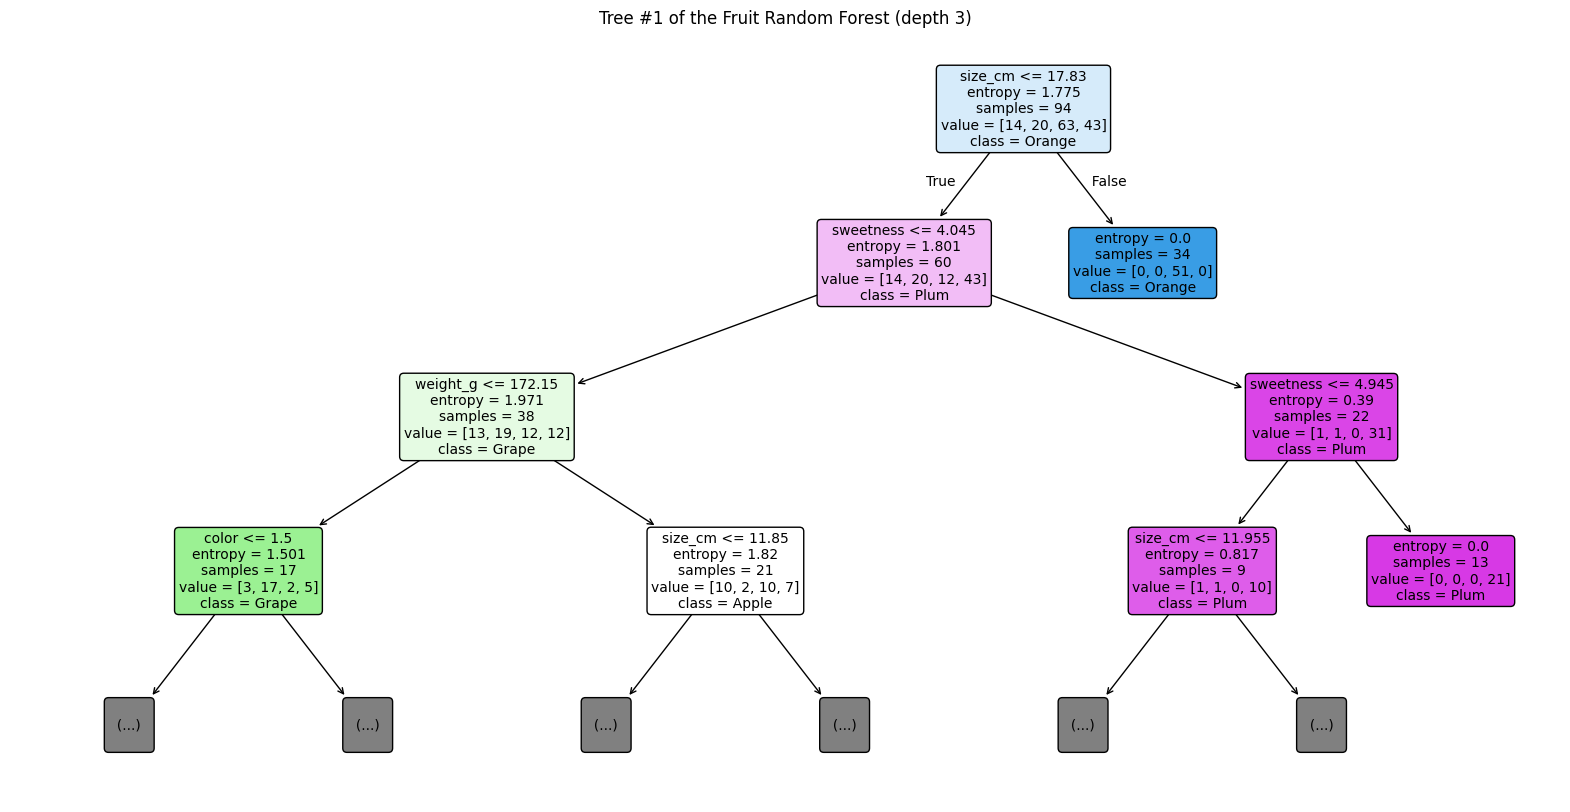

In [12]:
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[0],
          feature_names=X.columns.tolist(),
          class_names=fruit_le.classes_,
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Tree #1 of the Fruit Random Forest (depth 3)')
plt.show()

In [13]:
# Feature Importance

     Feature  Importance
1    size_cm    0.601905
2   weight_g    0.233858
3  sweetness    0.118862
0      color    0.045375


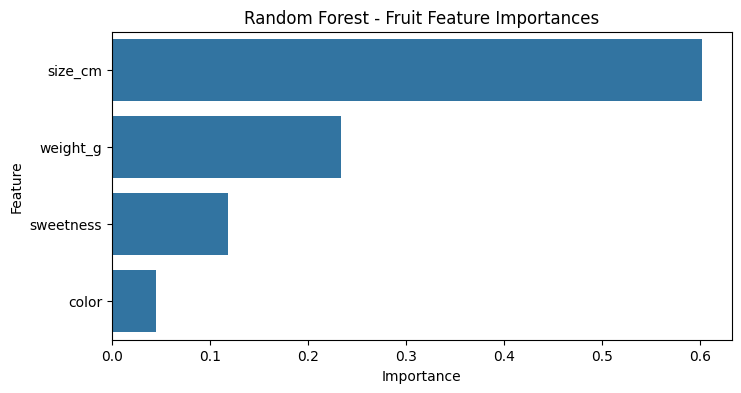

In [14]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_,
}).sort_values('Importance', ascending=False)
print(importance)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Random Forest - Fruit Feature Importances')
plt.show()

In [15]:
# Inspect per-tree votes for a single test sample

In [16]:
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
print("Sample #" + str(sample_idx) + " features:")
print(X_test.iloc[[sample_idx]])
print()
print("True class:", fruit_le.classes_[y_test.iloc[sample_idx]])

votes = []
for i, tree in enumerate(model.estimators_):
    v = int(tree.predict(sample)[0])
    votes.append(v)
    print("  Tree " + str(i+1).ljust(2) + " voted:", fruit_le.classes_[v])

from collections import Counter
vote_counts = Counter(votes)
print()
print("Vote tally:")
for cls_int, count in vote_counts.most_common():
    print("  " + fruit_le.classes_[cls_int] + ": " + str(count) + " votes")
print()
print("Final RF prediction (majority vote):",
      fruit_le.classes_[int(model.predict(sample)[0])])

Sample #0 features:
     color  size_cm  weight_g  sweetness
161      1    12.56    374.09       5.22

True class: Plum
  Tree 1  voted: Plum
  Tree 2  voted: Plum
  Tree 3  voted: Plum
  Tree 4  voted: Plum
  Tree 5  voted: Plum
  Tree 6  voted: Plum
  Tree 7  voted: Plum
  Tree 8  voted: Plum
  Tree 9  voted: Plum
  Tree 10 voted: Plum

Vote tally:
  Plum: 10 votes

Final RF prediction (majority vote): Plum


/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier 